In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from datetime import datetime, timedelta

In [3]:
# Load data
data = pd.read_csv('./methylphenidate_data.csv')

In [4]:
# Rename and parse 'Year Month' (YYYYMM) to datetime (month start)
data = data.rename(columns={'Year Month': 'Month'})

data['Month'] = data['Month'].astype(str).str.strip()
data['Month_dt'] = pd.to_datetime(data['Month'], format='%Y%m', errors='coerce')

# Optional pretty string
data['Month_str'] = data['Month_dt'].dt.strftime('%d/%m/%Y')


C:\Users\Andrew.Brown\AppData\Local\Temp\ipykernel_23348\1195618926.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


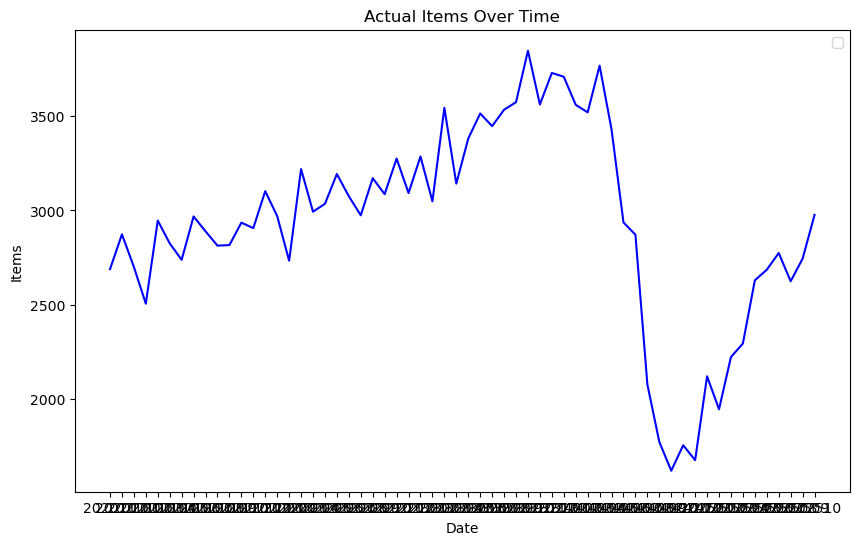

In [9]:
# Plot actual item data
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(data['Month'], data['Items'], color='blue')  # Plot the actual data

# Add titles and labels
plt.title('Actual Items Over Time')
plt.xlabel('Date')
plt.ylabel('Items')

# Add a legend
plt.legend()

# Display the plot
plt.show()

In [10]:
# Curtail the data to base regression AFTER a cutoff date if necessary (e.g. due to supply shock resulting from drug shortage)
cutoff = pd.Timestamp('2024-12-01')
data_to_regress = data[data['Month_dt'] >= cutoff].copy()

In [11]:
# Create months-since-start index for regression, where 0 = cutoff month
first_month = data_to_regress['Month_dt'].min()
start_month_count = first_month.year * 12 + first_month.month

data_to_regress['Month_Num'] = (
    data_to_regress['Month_dt'].dt.year * 12 + data_to_regress['Month_dt'].dt.month
) - start_month_count

# Sense check
print("First few Month_Num:\n", data_to_regress[['Month_dt', 'Month_Num']].head())


First few Month_Num:
      Month_dt  Month_Num
49 2024-12-01          0
50 2025-01-01          1
51 2025-02-01          2
52 2025-03-01          3
53 2025-04-01          4


In [ ]:
# Fit linear regression
X = data_to_regress[['Month_Num']].values  # shape (n,1)
y = data_to_regress['Items'].values
model = LinearRegression()
model.fit(X, y)
print("Model slope (items per month):", model.coef_[0])
print("Model intercept:", model.intercept_)

# Set date range to forecast
first_month = data_to_regress['Month_dt'].min()
start_month_count = first_month.year * 12 + first_month.month
last_month = data_to_regress['Month_dt'].max()
forecast_end = pd.Timestamp('2027-03-01')

# Build future months (month starts) from the month after last observed until forecast_end
future_months = pd.date_range(
    start=last_month + pd.DateOffset(months=1),
    end=forecast_end,
    freq='MS'
)

# numeric month index for forecast (consistent with Month_Num)
future_month_nums = ((future_months.year * 12 + future_months.month) - start_month_count)
future_X = future_month_nums.to_numpy().reshape(-1, 1)
future_items = model.predict(future_X)

forecast_item_data = pd.DataFrame({
    'Month_dt': future_months,
    'Month_Num': future_month_nums,
    'Items': future_items
})

# Prepare plotting frames
plot_obs = data_to_regress[['Month_dt', 'Items']].copy()
plot_fore = forecast_item_data[['Month_dt', 'Items']].copy()

# Dynamic label
n_forecast = len(future_months)
forecast_label = f'Forecast ({n_forecast} months → {future_months.max().strftime("%b %Y")})'

## Sense checks
print("SENSE CHECKS:")
print("Last observed month:", last_month.date())
if len(future_months) > 0:
    print("Forecast start:", future_months.min().date())
    print("Forecast end:", future_months.max().date())
print("Number of forecast months:", len(future_months))

# Last observed Month_Num and first future Month_Num should be sequential
print("Last observed Month_Num:", data_to_regress['Month_Num'].iloc[-1])
print("First future Month_Num:", future_month_nums[0])


# Plot observed, fit (on observed), and forecast
plt.figure(figsize=(11, 6))
plt.scatter(plot_obs['Month_dt'], plot_obs['Items'], label='Observed', color='tab:blue', zorder=3)
plt.plot(plot_obs['Month_dt'], model.predict(X), label='Fit', color='tab:green', linewidth=2, zorder=2)
plt.plot(plot_fore['Month_dt'], plot_fore['Items'],
        label=forecast_label, color='tab:red', linestyle='--', marker='x', zorder=4)

plt.title(f'Methylphenidate prescribing — post-Dec-2024 trend + forecast to {future_months.max().strftime("%b %Y")}')
plt.ylabel('Items')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Model slope (items per month): 113.93636363636367
Model intercept: 1856.4999999999995
SENSE CHECKS:
Last observed month: 2025-10-01
Forecast start: 2025-11-01
Forecast end: 2027-03-01
Number of forecast months: 17
Last observed Month_Num: 10


NameError: name 'future_month_nums' is not defined

In [ ]:
# See last 12m actual data
print(data_to_regress.tail(12))

     Month  Items   Actual Cost   Month_dt   Month_str  Month_Num
49  202412   1675   80027.55628 2024-12-01  01/12/2024          0
50  202501   2120   99180.43007 2025-01-01  01/01/2025          1
51  202502   1945   91754.19616 2025-02-01  01/02/2025          2
52  202503   2222   95508.85783 2025-03-01  01/03/2025          3
53  202504   2294   94593.97088 2025-04-01  01/04/2025          4
54  202505   2629  107160.85330 2025-05-01  01/05/2025          5
55  202506   2685  107409.17960 2025-06-01  01/06/2025          6
56  202507   2774  111489.08700 2025-07-01  01/07/2025          7
57  202508   2624  103847.19890 2025-08-01  01/08/2025          8
58  202509   2744  109105.89890 2025-09-01  01/09/2025          9
59  202510   2976  117251.31290 2025-10-01  01/10/2025         10


In [9]:
# See forecast item data
print(forecast_item_data)

     Month_dt  Month_Num        Items
0  2025-11-01         11  3109.800000
1  2025-12-01         12  3223.736364
2  2026-01-01         13  3337.672727
3  2026-02-01         14  3451.609091
4  2026-03-01         15  3565.545455
5  2026-04-01         16  3679.481818
6  2026-05-01         17  3793.418182
7  2026-06-01         18  3907.354545
8  2026-07-01         19  4021.290909
9  2026-08-01         20  4135.227273
10 2026-09-01         21  4249.163636
11 2026-10-01         22  4363.100000
12 2026-11-01         23  4477.036364
13 2026-12-01         24  4590.972727
14 2027-01-01         25  4704.909091
15 2027-02-01         26  4818.845455
16 2027-03-01         27  4932.781818


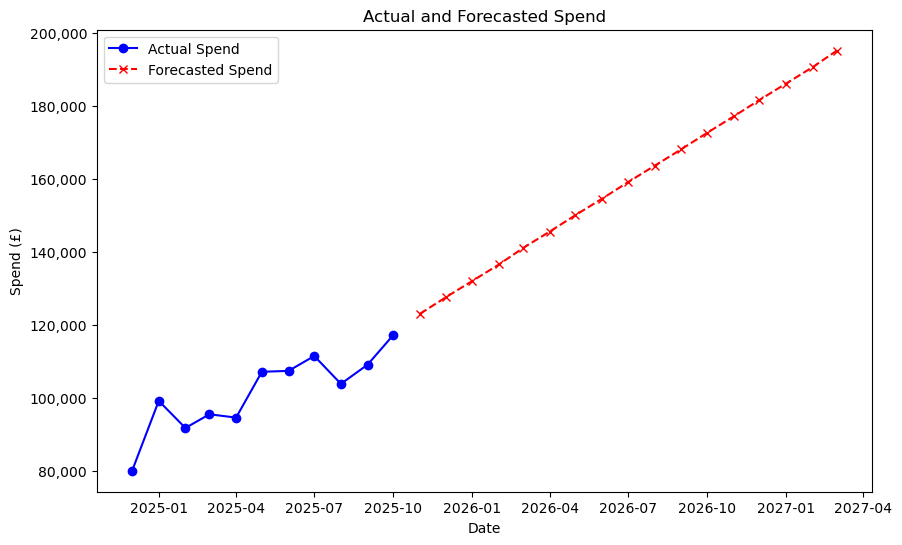

     Month_dt  Forecasted Spend
0  2025-11-01           123,067
1  2025-12-01           127,576
2  2026-01-01           132,085
3  2026-02-01           136,594
4  2026-03-01           141,102
5  2026-04-01           145,611
6  2026-05-01           150,120
7  2026-06-01           154,629
8  2026-07-01           159,138
9  2026-08-01           163,647
10 2026-09-01           168,156
11 2026-10-01           172,665
12 2026-11-01           177,174
13 2026-12-01           181,683
14 2027-01-01           186,191
15 2027-02-01           190,700
16 2027-03-01           195,209
57   103,847
58   109,106
59   117,251
Name: Actual Cost, dtype: float64
[1.11809684 1.15906149 1.20002615 1.2409908  1.28195546 1.32292012
 1.36388477 1.40484943 1.44581409 1.48677874 1.5277434  1.56870805
 1.60967271 1.65063737 1.69160202 1.73256668 1.77353133]


In [ ]:
## Applying item growth pattern to spend forecasting

# Calculate the proportional growth pattern from Items
recent_items = data_to_regress['Items'].tail(3).mean() # 3m default. But if recent item growth is unusually high and not expected to be sustained then use a longer tail to ensure that this is reflected in the growth rate when comparing against future items
growth_factor = future_items / recent_items  # Growth pattern based on items regression

# Apply growth factor to actual spend
recent_spend = data_to_regress['Actual Cost'].tail(3).mean() # 3m default. But if recent price growth is substantial then use a longer tail to dilute these unpredictable effects, unless there is reason there is reason to expect the price increase will be sustained.
future_spend = growth_factor * recent_spend

# Create a DataFrame for forecasted spend
forecast_spend_data = pd.DataFrame({
    'Month_dt': future_months[:len(future_spend)],  # Use the same number of months as forecasted spend
    'Forecasted Spend': future_spend
})

# Plots
plt.figure(figsize=(10, 6))

# Plot actual spend
plt.plot(data_to_regress['Month_dt'], data_to_regress['Actual Cost'], label='Actual Spend', color='blue', marker='o')

# Plot forecasted spend
plt.plot(forecast_spend_data['Month_dt'], forecast_spend_data['Forecasted Spend'],
         label='Forecasted Spend', color='red', linestyle='--', marker='x')

# Add titles and labels
plt.title('Actual and Forecasted Spend')
plt.xlabel('Date')
plt.ylabel('Spend (£)')
plt.legend()

# Format axis
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Display the plot
plt.show()

# Display forecasted spend data
pd.options.display.float_format = '{:,.0f}'.format
print(forecast_spend_data)

print(data['Actual Cost'].tail(3))
print(growth_factor)

In [11]:
# Rename columns in forecast_spend_data to match the actual spend data
forecast_spend_data.rename(columns={'Forecasted Spend': 'Actual Cost'}, inplace=True)

# Concatenate the two datasets
hybrid_data = pd.concat([data[['Month_dt', 'Actual Cost']], forecast_spend_data], ignore_index=True)

# Sort by 'Month_dt' to ensure chronological order
hybrid_data.sort_values(by='Month_dt', inplace=True)

# Reset the index
hybrid_data.reset_index(drop=True, inplace=True)

# Save the hybrid data to a CSV file
hybrid_data.to_csv('hybrid_data.csv', index=False)

print(hybrid_data)


     Month_dt  Actual Cost
0  2020-11-01       94,545
1  2020-12-01       99,539
2  2021-01-01       92,626
3  2021-02-01       85,784
4  2021-03-01       99,867
..        ...          ...
72 2026-11-01      177,174
73 2026-12-01      181,683
74 2027-01-01      186,191
75 2027-02-01      190,700
76 2027-03-01      195,209

[77 rows x 2 columns]


In [ ]:
# Define the date ranges for the two periods
previous_period_start = pd.Timestamp('2025-04-01')
previous_period_end = pd.Timestamp('2026-03-31')
forecast_period_start = pd.Timestamp('2026-04-01')
forecast_period_end = pd.Timestamp('2027-03-31')

# Filter the hybrid data for the previous period (2025-04-01 to 2026-03-31)
previous_period_data = hybrid_data[
    (hybrid_data['Month_dt'] >= previous_period_start) &
    (hybrid_data['Month_dt'] <= previous_period_end)
]

# Filter the hybrid data for the forecast period (2026-04-01 to 2027-03-31)
forecast_period_data = hybrid_data[
    (hybrid_data['Month_dt'] >= forecast_period_start) &
    (hybrid_data['Month_dt'] <= forecast_period_end)
]

,Month_dt,Actual Cost,Monthly_Reduction_Ramp,Target_Spend
0,2026-04-01,"£145,611.35","£1,938.97","£143,672.38"
1,2026-05-01,"£150,120.26","£3,877.95","£146,242.31"
2,2026-06-01,"£154,629.16","£5,816.92","£148,812.24"
3,2026-07-01,"£159,138.06","£7,755.90","£151,382.17"
4,2026-08-01,"£163,646.97","£9,694.87","£153,952.09"
5,2026-09-01,"£168,155.87","£11,633.85","£156,522.02"
6,2026-10-01,"£172,664.77","£13,572.82","£159,091.95"
7,2026-11-01,"£177,173.68","£15,511.79","£161,661.88"
8,2026-12-01,"£181,682.58","£17,450.77","£164,231.81"
9,2027-01-01,"£186,191.48","£19,389.74","£166,801.74"


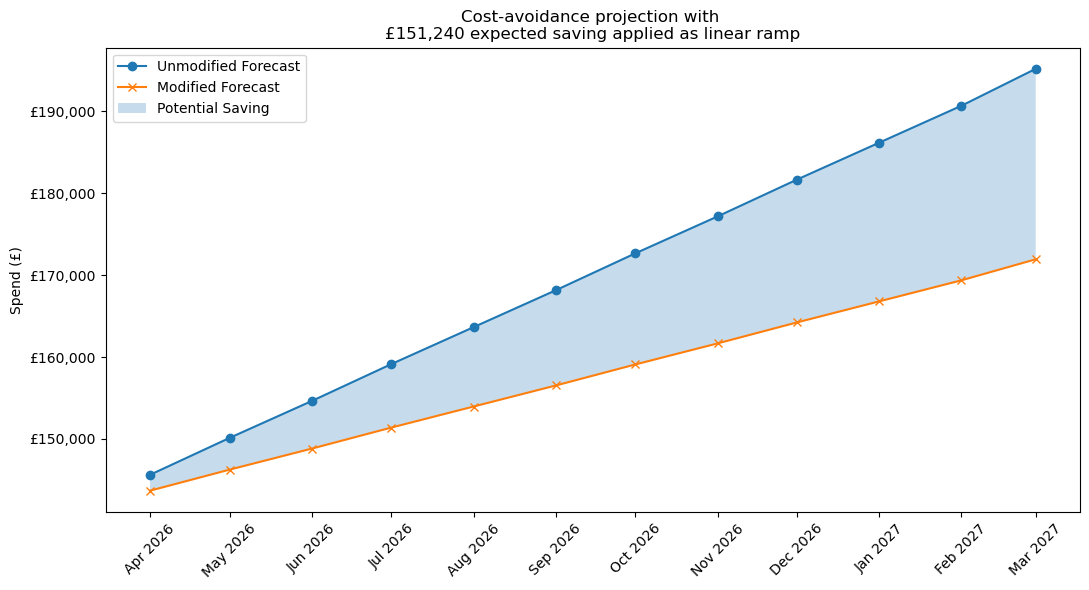

In [19]:
# Parameters
total_saving = 151240.0 ### USER DEFINED
date_col = 'Month_dt'
forecast_col = 'Actual Cost'

# Copy & sort (safety)
target_df = forecast_period_data.copy().sort_values(date_col).reset_index(drop=True)

n = len(target_df)
if n == 0:
    raise ValueError("forecast_period_data contains no rows.")

# Linear ramp weights: 1..n
weights = np.arange(1, n + 1, dtype=float)
weights /= weights.sum()

# Initial ramp allocation
reductions = weights * total_saving
forecast_vals = target_df[forecast_col].to_numpy(dtype=float)

# Cap reductions so no target goes below zero (iterative reallocation)
fixed = np.zeros(n, dtype=bool)
remaining = total_saving
base_weights = weights.copy()

for _ in range(20):  # safety cap
    free = ~fixed
    if not free.any():
        break

    # redistribute remaining saving across unfixed months
    w = base_weights[free]
    w = w / w.sum()
    reductions[free] = w * remaining

    # cap months where reduction exceeds forecast
    over = reductions > forecast_vals
    if not over.any():
        break

    reductions[over] = forecast_vals[over]
    fixed[over] = True
    remaining = total_saving - reductions.sum()

# Final targets
target_df['Monthly_Reduction_Ramp'] = reductions
target_df['Target_Spend'] = target_df[forecast_col] - target_df['Monthly_Reduction_Ramp']

# Display table
pd.options.display.float_format = '£{:,.2f}'.format
display(target_df[[date_col, forecast_col, 'Monthly_Reduction_Ramp', 'Target_Spend']])

# Plot
plt.figure(figsize=(11, 6))
plt.plot(target_df[date_col], target_df[forecast_col],
         label='Unmodified Forecast', marker='o')
plt.plot(target_df[date_col], target_df['Target_Spend'],
         label='Modified Forecast', marker='x')

plt.fill_between(
    target_df[date_col],
    target_df['Target_Spend'],
    target_df[forecast_col],
    alpha=0.25,
    label='Potential Saving'
)

plt.title(f'Cost-avoidance projection with \n£{total_saving:,.0f} expected saving applied as linear ramp')
plt.ylabel('Spend (£)')
plt.legend()
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('£{x:,.0f}'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Merge modified_forecast_spend_data into hybrid_data based on the Month column
cols_to_merge = [
    'Month_dt',
    'Monthly_Reduction_Ramp',
    'Target_Spend'
]

hybrid_modified_data = hybrid_data.merge(
    target_df[cols_to_merge],
    on='Month_dt',
    how='left'
)

# Output the combined data
print(hybrid_modified_data)

# Save the hybrid data to a CSV file
hybrid_modified_data.to_csv('hybrid_modified_data.csv', index=False)

     Month_dt  Actual Cost  Monthly_Reduction_Ramp  Target_Spend
0  2020-11-01   £94,545.04                     NaN           NaN
1  2020-12-01   £99,539.19                     NaN           NaN
2  2021-01-01   £92,626.24                     NaN           NaN
3  2021-02-01   £85,783.67                     NaN           NaN
4  2021-03-01   £99,866.70                     NaN           NaN
..        ...          ...                     ...           ...
72 2026-11-01  £177,173.68              £15,511.79   £161,661.88
73 2026-12-01  £181,682.58              £17,450.77   £164,231.81
74 2027-01-01  £186,191.48              £19,389.74   £166,801.74
75 2027-02-01  £190,700.39              £21,328.72   £169,371.67
76 2027-03-01  £195,209.29              £23,267.69   £171,941.60

[77 rows x 4 columns]


In [20]:
### Extracurricular

# Calculate monthly growth rates in the forecast period
forecast_period_data['Growth_Rate'] = forecast_period_data['Actual Cost'].pct_change()

# Calculate the average monthly growth rate (ignoring NaN from the first row)
average_monthly_growth_rate = forecast_period_data['Growth_Rate'].mean()

# Convert to percentage for display
average_monthly_growth_rate_percentage = average_monthly_growth_rate * 100

print(f"Average Monthly Growth Rate in Forecast Period: {average_monthly_growth_rate_percentage:.4f}%")

Average Monthly Growth Rate in Forecast Period: 2.7009%


C:\Users\Andrew.Brown\AppData\Local\Temp\ipykernel_11840\4280484464.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  forecast_period_data['Growth_Rate'] = forecast_period_data['Actual Cost'].pct_change()


In [21]:
# Calculate the annual growth rate from the average monthly growth rate
annual_growth_rate = (1 + average_monthly_growth_rate) ** 12 - 1

# Convert to percentage for display
annual_growth_rate_percentage = annual_growth_rate * 100

print(f"Annual Growth Rate Expected within Forecast Period: {annual_growth_rate_percentage:.4f}%")


Annual Growth Rate Expected within Forecast Period: 37.6866%


     Month_dt  Actual Cost_x  Actual Cost_y  Monthly_Reduction_Ramp  \
0  2020-11-01     £94,545.04            NaN                     NaN   
1  2020-12-01     £99,539.19            NaN                     NaN   
2  2021-01-01     £92,626.24            NaN                     NaN   
3  2021-02-01     £85,783.67            NaN                     NaN   
4  2021-03-01     £99,866.70            NaN                     NaN   
..        ...            ...            ...                     ...   
72 2026-11-01    £177,173.68    £177,173.68              £15,511.79   
73 2026-12-01    £181,682.58    £181,682.58              £17,450.77   
74 2027-01-01    £186,191.48    £186,191.48              £19,389.74   
75 2027-02-01    £190,700.39    £190,700.39              £21,328.72   
76 2027-03-01    £195,209.29    £195,209.29              £23,267.69   

    Target_Spend  
0            NaN  
1            NaN  
2            NaN  
3            NaN  
4            NaN  
..           ...  
72   £161,661.